In [8]:
# Load images

import digiagro_helper as helper
import torch
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

img_dir = 'data/'

class_subdirs = [
    # Class 0
    # (subdir, weight)
    [('dirt-samsung', 1.5),   # lettuce dataset
     ('dirt-dji', 1.5),       # lettuce dataset
     ('dirt-light', 1.0),     # potato leaves dataset
     ('dirt-normal', 1.0),    # potato leaves dataset
     ('dirt-dark', 1.0)],     # potato leaves dataset
    # Class 1
    [('plants-samsung', 1.5), # lettuce dataset
     ('plants-dji', 1.5),     # lettuce dataset
     ('plants-light', 1.0),   # potato leaves dataset
     ('plants-normal', 1.0),  # potato leaves dataset
     ('plants-dark', 1.0)]]   # potato leaves dataset

n_classes = len(class_subdirs)
global_imgs = helper.read_imgs(img_dir, class_subdirs)

for i in range(n_classes):
    print(f'Loaded {len(global_imgs[i])} images for class {i}')

Loaded 70 images for class 0
Loaded 70 images for class 1


In [9]:
# Logistic regression

from sklearn.linear_model import LogisticRegression

batch_sz = 1000 * 1000
# Increase to decrease the variance in the average validation accuracy
n_runs = 10
val_accs = np.zeros(n_runs)

for data_split_nr in tqdm(range(n_runs)):
    imgs_train, imgs_val = helper.xval(global_imgs)

    train_loader = helper.data_loader(imgs_train, batch_sz)
   
    mu, std = helper.feats_mean_std(train_loader, 1)

    X, y = next(train_loader)
    # Normalize
    X = (X - mu) / std
    
    model = LogisticRegression().fit(X, y)    
            
    val_loader = helper.data_loader(imgs_val, batch_sz)    
    X, y = next(val_loader) # just 1 minibatch    
    X = (X - mu) / std
    
    y_pred = model.predict(X)
    val_accs[data_split_nr] = (y_pred == y).sum() / y.shape[0]

print(f'avg val acc: {val_accs.mean():.4f} ± {val_accs.std():.4f}')

100%|██████████| 10/10 [00:15<00:00,  1.57s/it]

avg val acc: 0.9672 ± 0.0149


In [10]:
# Train on all images

batch_sz = 1000 * 1000
train_loader = helper.data_loader(global_imgs, batch_sz)
   
mu, std = helper.feats_mean_std(train_loader, 1)

X, y = next(train_loader)
X = (X - mu) / std
model = LogisticRegression().fit(X, y) 

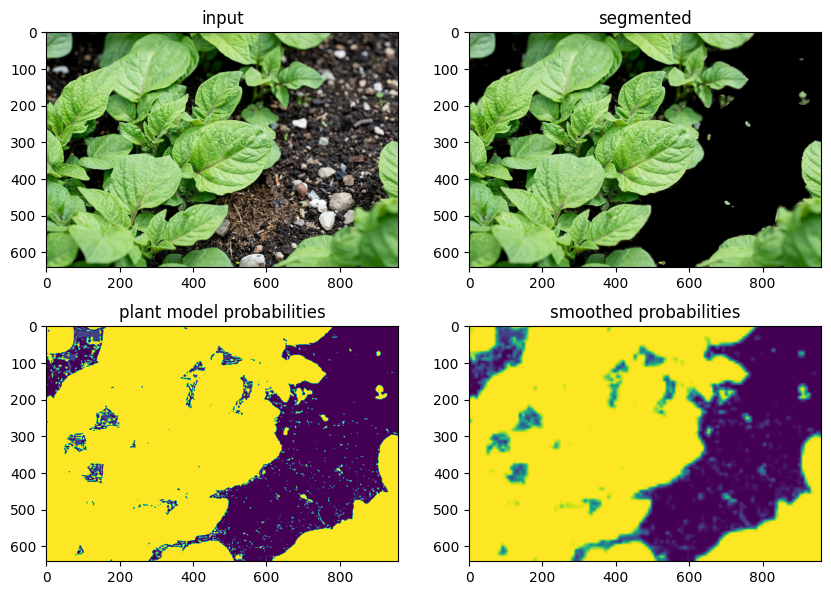

In [ ]:
# Test image not in the dataset

# Parameters

ds = 8            # downscale factor for probability smoothing
p_threshold = 0.5 # (average) probability threshold

import cv2

# source: https://cdn.pixabay.com/photo/2021/06/08/17/00/potato-6321127_960_720.jpg
img = cv2.imread('data/potato-6321127_960_720.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

width = img.shape[1]
height = img.shape[0]

X = img[..., 0:3].reshape(-1, 3)
X = (X - mu) / std

scalar = model.predict_proba(X)
scalar = scalar[..., 1].reshape(img.shape[0:2])
scalar_orig = scalar
scalar = cv2.resize(scalar, (width // ds, height // ds), interpolation=cv2.INTER_AREA)
scalar = cv2.resize(scalar, (width, height), interpolation=cv2.INTER_LINEAR)

fig, axes = plt.subplots(2, 2, figsize=(10,7))
axes[0][0].imshow(img)
axes[0][0].set_title('input')
img2 = img.copy()
img2[scalar < p_threshold, :] = 0
axes[0][1].imshow(img2)
axes[0][1].set_title('segmented')
axes[1][0].imshow(scalar_orig)
axes[1][0].set_title('plant model probabilities')
axes[1][1].imshow(scalar)
axes[1][1].set_title('smoothed probabilities');


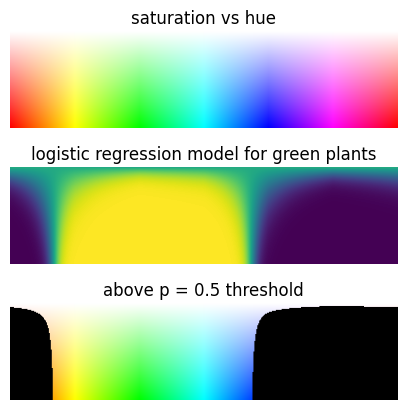

In [12]:
# Check which colors are classified as plants
# Also depends here on the brightness (val) variable

hue = np.linspace(0, 360, 400, dtype=np.float32)
sat = np.linspace(0, 1, 100, dtype=np.float32)
val = 1 * np.ones((100, 400), dtype=np.float32)
x, y = np.meshgrid(hue, sat)

vals = np.stack((x, y, val), 2)

img = cv2.cvtColor(vals, cv2.COLOR_HSV2RGB)

scalar = model.predict_proba(img.reshape(-1, 3))

scalar = scalar[..., 1].reshape(img.shape[0:2])

fig, axes = plt.subplots(3, 1, figsize=(5,5))
axes[0].imshow(img)
axes[0].set_title('saturation vs hue')
axes[0].set_axis_off()
axes[1].set_title('logistic regression model for green plants')
axes[1].imshow(scalar)
axes[1].set_axis_off()
img[scalar < p_threshold, :] = 0
axes[2].set_title(f'above p = {p_threshold} threshold')
axes[2].imshow(img)
axes[2].set_axis_off();